In [10]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [3]:
df = pd.read_csv(r"C:\DataScience\Deep Learning\Optimizers\diabetes.csv")

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# correlation btw them

df.corr()['Outcome']

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

In [11]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [13]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [19]:
model = Sequential()

model.add(Dense(32,activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(1,activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [30]:
history = model.fit(X_train_scaled, y_train, batch_size=32, epochs=100, validation_split=0.2)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8187 - loss: 0.3966 - val_accuracy: 0.7886 - val_loss: 0.3941
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8208 - loss: 0.3960 - val_accuracy: 0.7886 - val_loss: 0.3972
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8147 - loss: 0.3959 - val_accuracy: 0.7967 - val_loss: 0.4012
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8065 - loss: 0.3959 - val_accuracy: 0.7805 - val_loss: 0.4008
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8106 - loss: 0.3937 - val_accuracy: 0.7886 - val_loss: 0.4033
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8126 - loss: 0.3934 - val_accuracy: 0.7967 - val_loss: 0.4048
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8126 - loss: 0.3927 - val_accuracy: 0.7967 - val_loss: 0.4050
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8126 - loss: 0.3924 - val_accuracy: 0.

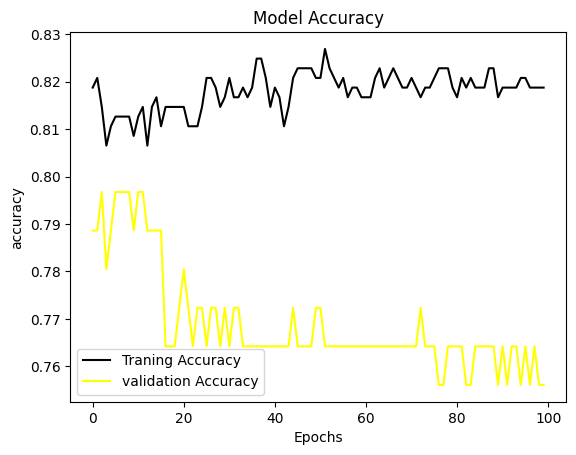

In [32]:
plt.plot(history.history['accuracy'],c='black', label='Traning Accuracy')
plt.plot(history.history['val_accuracy'],c='yellow', label='validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()